# AkidaNet on ImageNet - Hardware Benchmark

<p align="right">Run Time: ~10 minutes</p>

Measures what an AkidaNet ImageNet model actually costs on Akida hardware: inference
latency, the mapping onto Neural Processors, power, and where the time goes layer by layer.

This notebook needs no dataset setup - it runs from a 10-image sample pack fetched
automatically.

> **Requires a connected AKD1500 device.** The power measurements are read live over I2C.
> This will not run on Colab.

## Configuration

Use the following cell to choose the target model by alpha value (0.25, 0.5 or 1.0) and input resolution (160 or 224).

In [1]:
import numpy as np
import akida

ALPHA = 1.0          # 0.25, 0.5 or 1.0
RESOLUTION = 224     # 160 or 224

NUM_SAMPLES = 100    # inferences per benchmark
POWER_REPEATS = 5    # Repeats of the power measurements
CLOCK_FREQUENCY = 400e6   # 400 MHz for AKD1500

INPUT_SHAPE = (RESOLUTION, RESOLUTION, 3)
print(f'Model: alpha={ALPHA}, {RESOLUTION}x{RESOLUTION}')

Model: alpha=1.0, 224x224


## Model

The converted Akida model, straight from `pretrained_models/`. These files are tracked with
Git LFS - if you get a parse error here, run `git lfs pull`.

In [2]:
from imagenet_akidanet_model import model_path

akida_model = akida.Model(str(model_path(ALPHA, RESOLUTION, 'akida')))
akida_model.summary()

2026-08-10 12:57:35.339809: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786359455.352471    4426 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786359455.356380    4426 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786359455.366164    4426 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786359455.366176    4426 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786359455.366178    4426 computation_placer.cc:177] computation placer alr

                 Model Summary                  
________________________________________________
Input shape    Output shape  Sequences  Layers
[224, 224, 3]  [1, 1, 1000]  1          15    
________________________________________________

______________________________________________________________
Layer (type)              Output shape    Kernel shape      

=============== SW/conv_0-classifier (Software) ==============

conv_0 (InputConv.)       [112, 112, 32]  (3, 3, 3, 32)     
______________________________________________________________
conv_1 (Conv.)            [112, 112, 64]  (3, 3, 32, 64)    
______________________________________________________________
conv_2 (Conv.)            [56, 56, 128]   (3, 3, 64, 128)   
______________________________________________________________
conv_3 (Conv.)            [56, 56, 128]   (3, 3, 128, 128)  
______________________________________________________________
separable_4 (Sep.Conv.)   [28, 28, 256]   (3, 3, 128, 1)    
____________

## Samples

Akida is event-driven: a zero activation produces no event and therefore no work. Latency
and power both depend on how sparse the activations are, which depends on the input. So the
benchmark must run on real images - random noise gives the wrong activity statistics and
therefore the wrong numbers.

Ten real images, cycled, capture those statistics well enough. Pass `data_path` to
`get_samples` to draw from the ImageNet validation set instead, if you have it set up.

In [3]:
from imagenet_akidanet_data import get_samples

samples = get_samples(INPUT_SHAPE, num_samples=NUM_SAMPLES)
print(f'{samples.shape} {samples.dtype}, range [{samples.min()}, {samples.max()}]')

(100, 224, 224, 3) uint8, range [0, 255]


## Hardware device detection

`get_akida_device` checks for a device matching the model's IP version, so a v1 model does
not get mapped onto v2 silicon.

In [4]:
from brainchip_utils.hardware_utils import get_akida_device

device = get_akida_device(target_version=akida_model.ip_version)
if device is not None:
    print(f'Akida hardware found: {device}')
else:
    print('No hardware found - the benchmark sections below will be skipped.')

Target Akida device found
Akida hardware found: <akida.core.HardwareDevice object at 0x7f1f90653bf0>


## Activation sparsity

Worth looking at before the timings, because it predicts them. Layers with high sparsity
are the ones the hardware gets through quickly.

In [5]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity

sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)
print(f'\nMean activation sparsity: {np.mean(list(sparsity_dict.values())) * 100:.2f}%')


Layer            Sparsity
-------------------------
conv_0            47.00%
conv_1            60.51%
conv_2            66.83%
conv_3            48.61%
separable_4       62.04%
separable_5       72.48%
separable_6       48.03%
separable_7       60.19%
separable_8       68.85%
separable_9       75.54%
separable_10      82.02%
separable_11      67.25%
separable_12      91.56%
separable_13      69.77%
classifier         0.29%
-------------------------
Mean              61.40%

Mean activation sparsity: 61.40%


## Simple benchmark

A first timing pass in `Minimal` mapping mode at batch size 1, comparing two clocks: the
host's `perf_counter_ns` and the device's own inference clock counter. They should agree
closely - if they do not, the gap is host-side overhead rather than device time.

In [6]:
import time

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)
    # Run a priming frame
    akida_model.forward(samples[0:1], batch_size=1)

    inf_clks, inf_times = [], []
    for rr in range(NUM_SAMPLES):
        start_t = time.perf_counter_ns()
        akida_model.forward(samples[rr:rr + 1], batch_size=1)
        inf_times.append(time.perf_counter_ns() - start_t)
        inf_clks.append(akida_model.metrics['inference_clk'])

    mean_inf_clk = np.mean(inf_clks) / CLOCK_FREQUENCY * 1e3   # s to ms
    mean_inf_time = np.mean(inf_times) * 1e-6                  # ns to ms
    print(f'Mean inference time (system clock):        {mean_inf_time:.3f} ms')
    print(f'Mean on-chip time (via chip clock cycles): {mean_inf_clk:.3f} ms')
else:
    print('No hardware - skipping.')

Mean inference time (system clock):        133.889 ms
Mean on-chip time (via chip clock cycles): 126.296 ms


## Full model benchmark

Three mapping modes, measured with power:

- **Minimal** packs the model onto the fewest Neural Processors it fits in, keeping power low.
- **AllNPs** spreads it across more NPs while keeping the number of hardware passes down,
  raising power somewhat but cutting latency roughly in proportion.
- **HwPr** also uses every NP it can, but splits the work over more passes rather than
  minimising them, which can cut latency further still.

None is universally better - it is a latency/power trade-off you choose per application.

In [7]:
from brainchip_utils.hardware_utils import full_model_benchmark, get_mapping_stats

full_results = {}
if device is not None:
    for mm in ['Minimal', 'AllNps', 'HwPr']:
        map_mode = getattr(akida.MapMode, mm)
        print(f'Running full-model benchmark (MapMode={mm}, {POWER_REPEATS} repeats)...')
        res = full_model_benchmark(akida_model, device, samples,
                                   map_mode=map_mode, repeats=POWER_REPEATS)
        if res is None:
            # Not every mode maps every model onto a single hardware sequence
            print(f'  MapMode={mm} did not map to hardware - skipping this mode.')
            continue
        full_results[mm] = res
        # Re-map without hw_only so akida_model.sequences is populated for the stats
        akida_model.map(device, mode=map_mode)
        num_nps, num_passes, num_sequences = get_mapping_stats(akida_model)
        full_results[mm]['num_nps'] = num_nps
        full_results[mm]['num_passes'] = num_passes
        print(f'  {num_nps} NP(s), {num_passes} pass(es), {num_sequences} sequence(s)')
        if num_sequences > 1:
            print('  WARNING: model not completely mapped to hardware')
else:
    print('No hardware - skipping.')

Running full-model benchmark (MapMode=Minimal, 5 repeats)...
Checking I2C power measurement hardware...
  I2C INA sensor detected — power measurement enabled.
  Supply voltage: 0.805 V
  Power measurement active.
  Repeat 1/5: recording floor (1.0 s)...
  Repeat 1/5 done.
  Repeat 2/5: recording floor (1.0 s)...
  Repeat 2/5 done.
  Repeat 3/5: recording floor (1.0 s)...
  Repeat 3/5 done.
  Repeat 4/5: recording floor (1.0 s)...
  Repeat 4/5 done.
  Repeat 5/5: recording floor (1.0 s)...
  Power process: 4756 ok, 0 errors
  Repeat 5/5 done.

  Mean inference time:    133.757 ms  (σ=1.508 ms)
  Mean on-chip time:      126.221 ms  (50488252 clocks)
  Total inferences run:   500
  Avg dynamic power:      108.6 mW
  Avg dynamic energy:     14.530 mJ/inf
  117 NP(s), 4 pass(es), 1 sequence(s)
Running full-model benchmark (MapMode=AllNps, 5 repeats)...
Checking I2C power measurement hardware...
  I2C INA sensor detected — power measurement enabled.
  Supply voltage: 0.805 V
  Power measurem

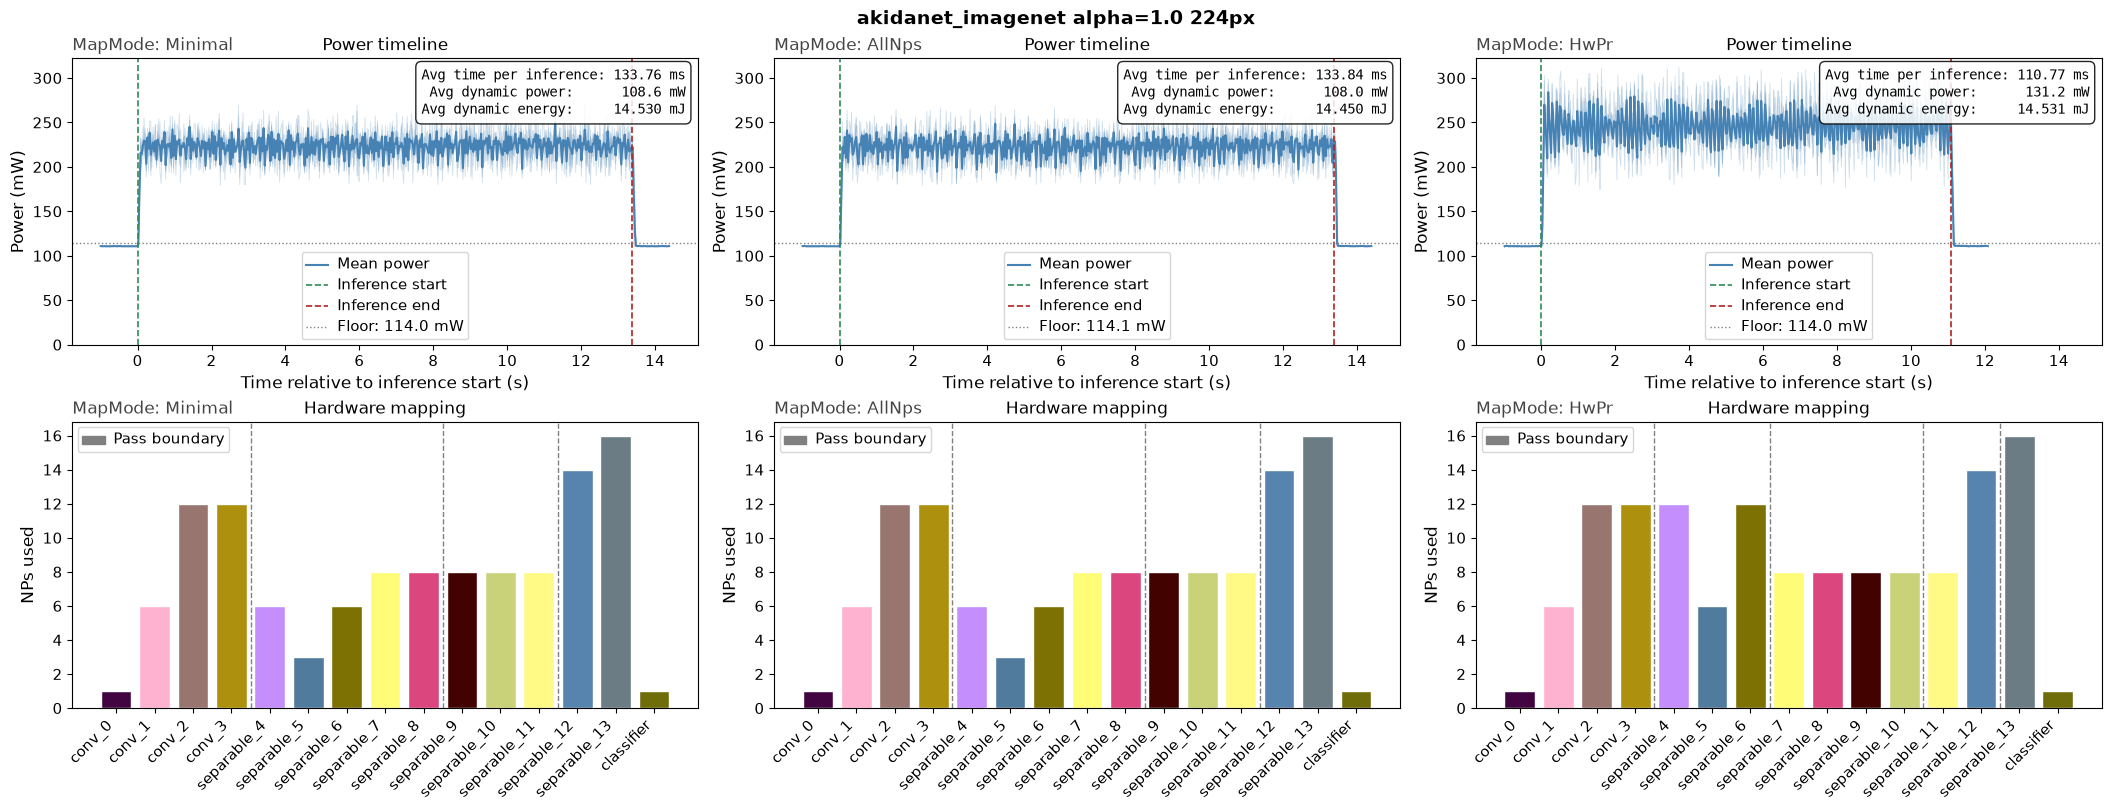

In [8]:
from brainchip_utils.plot_utils import plot_full_model_results

if device is not None:
    plot_full_model_results(full_results, akida_model, device,
                            model_name=f'akidanet_imagenet alpha={ALPHA} {RESOLUTION}px')

## Per-layer benchmark

Full-model timing tells us the total cost but not where time is spent.
`per_layer_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
reconstructs latency layer by layer by running cumulative sub-models and
differencing the results.

Layer processing time depends on the amount of processing a layer has to do: a
function of the volume of inputs to the layer (height, width, channels) and the
number of filters in the layer. On Akida, that also depends on the resources 
allocated to processing that layer, the number of NPs. Howeve, because Akida is
an 'event-based' processor, that is, it processes non-zero activations only, a 
layer's cost is proportional to its *input* sparsity: a layer receiving 90% sparse
inputs has far fewer events to process than one receiving 10% sparse inputs. The 
per-layer timing and the sparsity values computed above are therefore naturally 
correlated — layers receiving low-sparsity inputs are typically the latency 
bottlenecks.

In [9]:
from brainchip_utils.hardware_utils import per_layer_benchmark

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)
    print(f'Running per-layer benchmark ({NUM_SAMPLES} samples)...')
    per_layer_results = per_layer_benchmark(akida_model, device, samples, repeats=NUM_SAMPLES)
else:
    print('No hardware - skipping.')

Running per-layer benchmark (100 samples)...

Layer            Latency (ms)       Clocks
----------------------------------
conv_0                 2.0207
conv_1                 4.5513
conv_2                 8.7466
conv_3                 3.8040
separable_4           20.9730
separable_5           16.1416
separable_6           12.9319
separable_7            9.4888
separable_8            7.9382
separable_9            6.9331
separable_10           6.0475
separable_11           5.1858
separable_12          10.4122
separable_13           6.1779
classifier             4.9773
----------------------------------
Total                126.3300


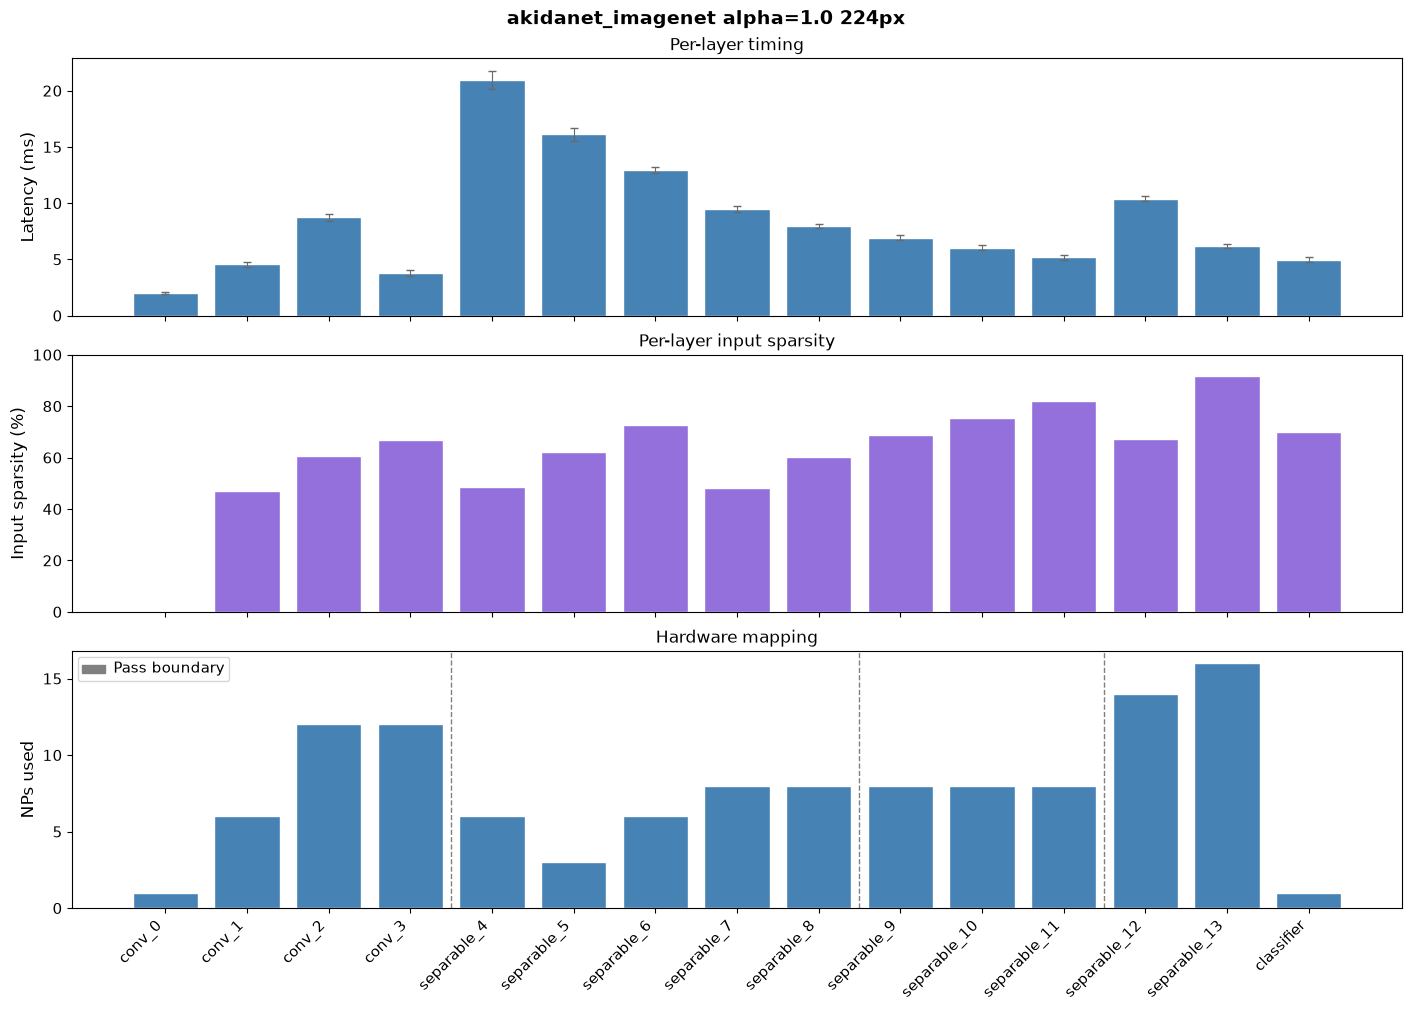

In [10]:
from brainchip_utils.plot_utils import plot_per_layer_results

if device is not None:
    # Map without hw_only so the mapping plot can be drawn
    akida_model.map(device, mode=akida.MapMode.Minimal)
    plot_per_layer_results(per_layer_results, akida_model, sparsity_dict,
                           model_name=f'akidanet_imagenet alpha={ALPHA} {RESOLUTION}px')

## Summary

In [11]:
print(f'AkidaNet alpha={ALPHA}, {RESOLUTION}x{RESOLUTION}')
print(f'  mean activation sparsity: {np.mean(list(sparsity_dict.values())) * 100:.2f}%')
if device is not None:
    for mm, res in full_results.items():
        line = (f'  {mm:8} {res["num_nps"]:3d} NPs, '
                f'{res["mean_clk_ms"]:7.3f} ms/inference')
        if res['power'] is not None:
            line += (f', {res["power"]["avg_total_mw"]:6.1f} mW total'
                     f', {res["power"]["avg_energy_mj"]:6.3f} mJ/inference')
        print(line)
else:
    print('  no hardware present - latency and power not measured')

AkidaNet alpha=1.0, 224x224
  mean activation sparsity: 61.40%
  Minimal  117 NPs, 126.221 ms/inference,  222.6 mW total, 29.779 mJ/inference
  AllNps   117 NPs, 126.292 ms/inference,  222.0 mW total, 29.719 mJ/inference
  HwPr     132 NPs, 103.211 ms/inference,  245.2 mW total, 27.160 mJ/inference
